In [1]:
!pip install bm3d opencv-python-headless mediapipe scipy matplotlib numpy -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 99.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 862.0/862.0 kB 55.5 MB/s eta 0:00:00


In [2]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyArrowPatch, Rectangle
from scipy import signal
from scipy.fft import fft2, fftshift
import cv2
import os

# ── Global style ─────────────────────────────────────────────────────────────
matplotlib.rcParams.update({
    'font.family':      'DejaVu Sans',
    'font.size':        11,
    'axes.titlesize':   12,
    'axes.titleweight': 'bold',
    'axes.labelsize':   10,
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'xtick.direction':  'out',
    'ytick.direction':  'out',
    'figure.dpi':       150,
    'savefig.dpi':      300,
    'savefig.bbox':     'tight',
    'savefig.pad_inches': 0.15,
})

PRIMARY   = '#0A3773'
ACCENT    = '#006EBE'
LIGHT     = '#DCF0FF'
SGREEN    = '#0F7837'
SRED      = '#AF1E1E'
SORANGE   = '#BE5A0A'
MIDGRAY   = '#6E6E6E'
DARKGRAY  = '#232323'

os.makedirs('figures', exist_ok=True)
print("✓ Imports done. Figures will be saved to ./figures/")


✓ Imports done. Figures will be saved to ./figures/


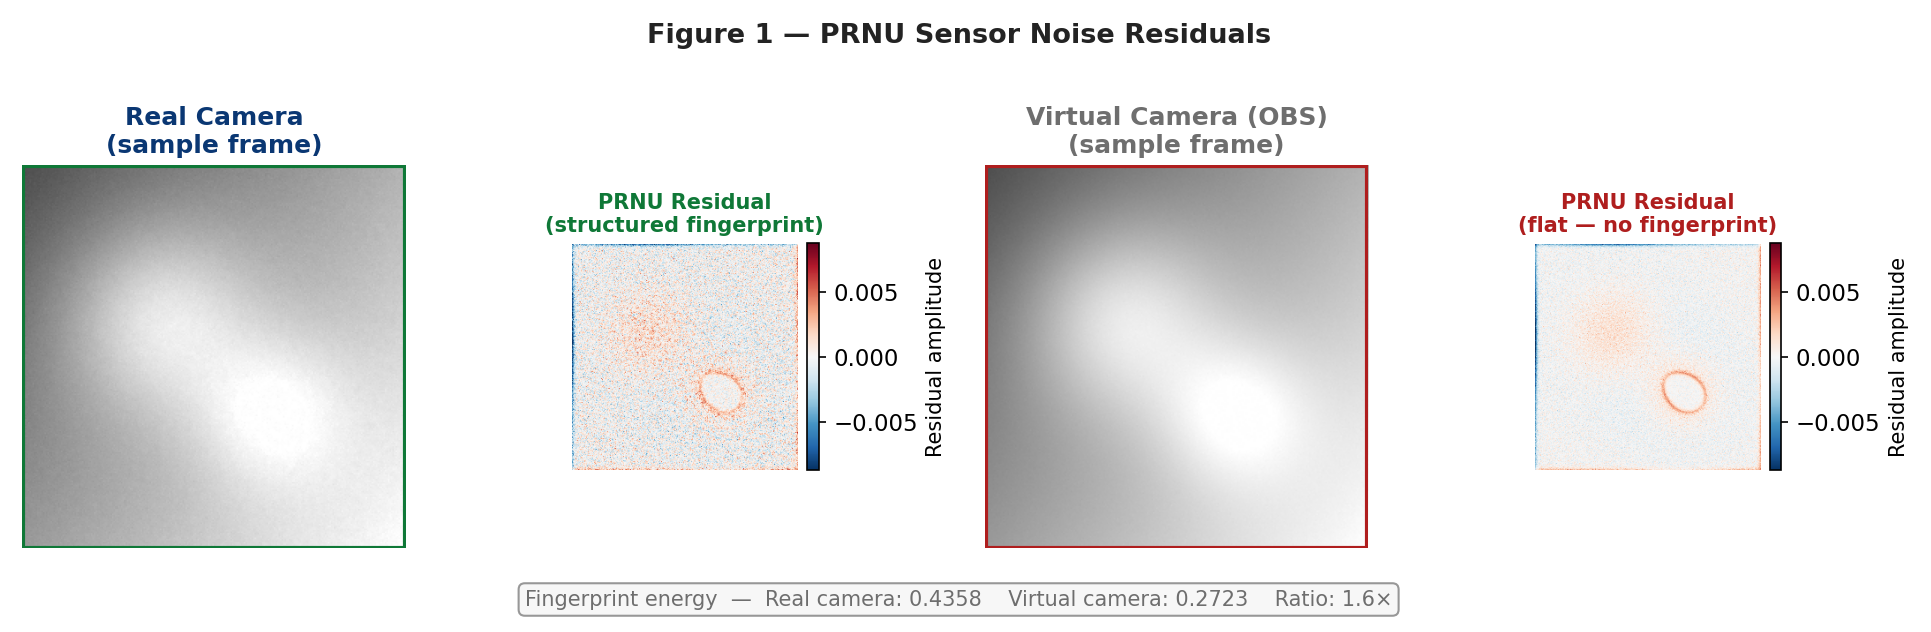

✓ Saved: figures/fig1_prnu_residuals.png


In [3]:
np.random.seed(42)

def simulate_physical_camera_frame(h=256, w=256, seed=0):
    """
    Simulate a single frame from a physical camera.
    Scene content (smooth gradient + shapes) + PRNU fingerprint + random noise.
    """
    rng = np.random.default_rng(seed)

    # Scene: smooth gradient with two blobs
    x, y = np.meshgrid(np.linspace(0, 1, w), np.linspace(0, 1, h))
    scene = (0.4 * x + 0.3 * y + 0.3).clip(0, 1)
    cx, cy, r = 0.35, 0.4, 0.18
    blob1 = np.exp(-((x - cx)**2 + (y - cy)**2) / (2 * r**2)) * 0.35
    cx2, cy2, r2 = 0.65, 0.65, 0.14
    blob2 = np.exp(-((x - cx2)**2 + (y - cy2)**2) / (2 * r2**2)) * 0.25
    scene = (scene + blob1 + blob2).clip(0, 1)

    # Fixed PRNU fingerprint (deterministic for this "device")
    prnu = rng.standard_normal((h, w)) * 0.018
    prnu = cv2.GaussianBlur(prnu.astype(np.float32), (5, 5), 1.2)

    # Random shot noise (different each frame)
    noise = rng.standard_normal((h, w)) * 0.008

    frame = (scene * (1 + prnu) + noise).clip(0, 1)
    return frame.astype(np.float32), prnu


def simulate_virtual_camera_frame(h=256, w=256, seed=0):
    """
    Simulate a software-rendered / virtual camera frame.
    Scene content only + tiny random noise — no PRNU structure.
    """
    rng = np.random.default_rng(seed + 99)

    x, y = np.meshgrid(np.linspace(0, 1, w), np.linspace(0, 1, h))
    scene = (0.4 * x + 0.3 * y + 0.3).clip(0, 1)
    cx, cy, r = 0.35, 0.4, 0.18
    blob1 = np.exp(-((x - cx)**2 + (y - cy)**2) / (2 * r**2)) * 0.35
    cx2, cy2, r2 = 0.65, 0.65, 0.14
    blob2 = np.exp(-((x - cx2)**2 + (y - cy2)**2) / (2 * r2**2)) * 0.25
    scene = (scene + blob1 + blob2).clip(0, 1)

    # No PRNU — only tiny uniform random noise
    noise = rng.standard_normal((h, w)) * 0.004
    frame = (scene + noise).clip(0, 1)
    return frame.astype(np.float32)


def extract_prnu_residual(frames):
    """
    Extract noise residual by subtracting a Gaussian-blurred version.
    Real BM3D denoiser would be used in production; Gaussian blur approximates
    the scene-content removal for visualisation purposes.
    """
    residuals = []
    for f in frames:
        denoised = cv2.GaussianBlur(f, (15, 15), 3.0)
        residuals.append(f - denoised)
    return np.mean(residuals, axis=0)


# ── Generate frames ───────────────────────────────────────────────────────────
N_FRAMES = 30
real_frames = [simulate_physical_camera_frame(seed=i)[0] for i in range(N_FRAMES)]
virt_frames = [simulate_virtual_camera_frame(seed=i)    for i in range(N_FRAMES)]

real_residual = extract_prnu_residual(real_frames)
virt_residual = extract_prnu_residual(virt_frames)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(13, 3.6),
                         gridspec_kw={'width_ratios': [2, 1.2, 2, 1.2]})
fig.suptitle('Figure 1 — PRNU Sensor Noise Residuals', fontsize=13,
             fontweight='bold', color=DARKGRAY, y=1.02)

# Real camera — sample frame
axes[0].imshow(real_frames[0], cmap='gray', vmin=0, vmax=1)
axes[0].set_title('Real Camera\n(sample frame)', color=PRIMARY)
axes[0].axis('off')
rect = Rectangle((0, 0), 255, 255, linewidth=2,
                 edgecolor=SGREEN, facecolor='none')
axes[0].add_patch(rect)

# Real PRNU residual heatmap
vmax = np.abs(real_residual).max() * 0.8
im1 = axes[1].imshow(real_residual, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
axes[1].set_title('PRNU Residual\n(structured fingerprint)', color=SGREEN,
                  fontsize=10)
axes[1].axis('off')
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04,
             label='Residual amplitude')

# Virtual camera — sample frame
axes[2].imshow(virt_frames[0], cmap='gray', vmin=0, vmax=1)
axes[2].set_title('Virtual Camera (OBS)\n(sample frame)', color=MIDGRAY)
axes[2].axis('off')
rect2 = Rectangle((0, 0), 255, 255, linewidth=2,
                  edgecolor=SRED, facecolor='none')
axes[2].add_patch(rect2)

# Virtual PRNU residual heatmap
im2 = axes[3].imshow(virt_residual, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
axes[3].set_title('PRNU Residual\n(flat — no fingerprint)', color=SRED,
                  fontsize=10)
axes[3].axis('off')
plt.colorbar(im2, ax=axes[3], fraction=0.046, pad=0.04,
             label='Residual amplitude')

# Energy annotation
e_real = np.linalg.norm(real_residual, 'fro')
e_virt = np.linalg.norm(virt_residual, 'fro')
fig.text(0.5, -0.06,
         f'Fingerprint energy  —  Real camera: {e_real:.4f}    '
         f'Virtual camera: {e_virt:.4f}    '
         f'Ratio: {e_real/e_virt:.1f}×',
         ha='center', fontsize=10, color=MIDGRAY,
         bbox=dict(boxstyle='round,pad=0.3', fc='#F5F5F5', ec=MIDGRAY, alpha=0.7))

plt.tight_layout()
plt.savefig('figures/fig1_prnu_residuals.png')
plt.show()
print("✓ Saved: figures/fig1_prnu_residuals.png")

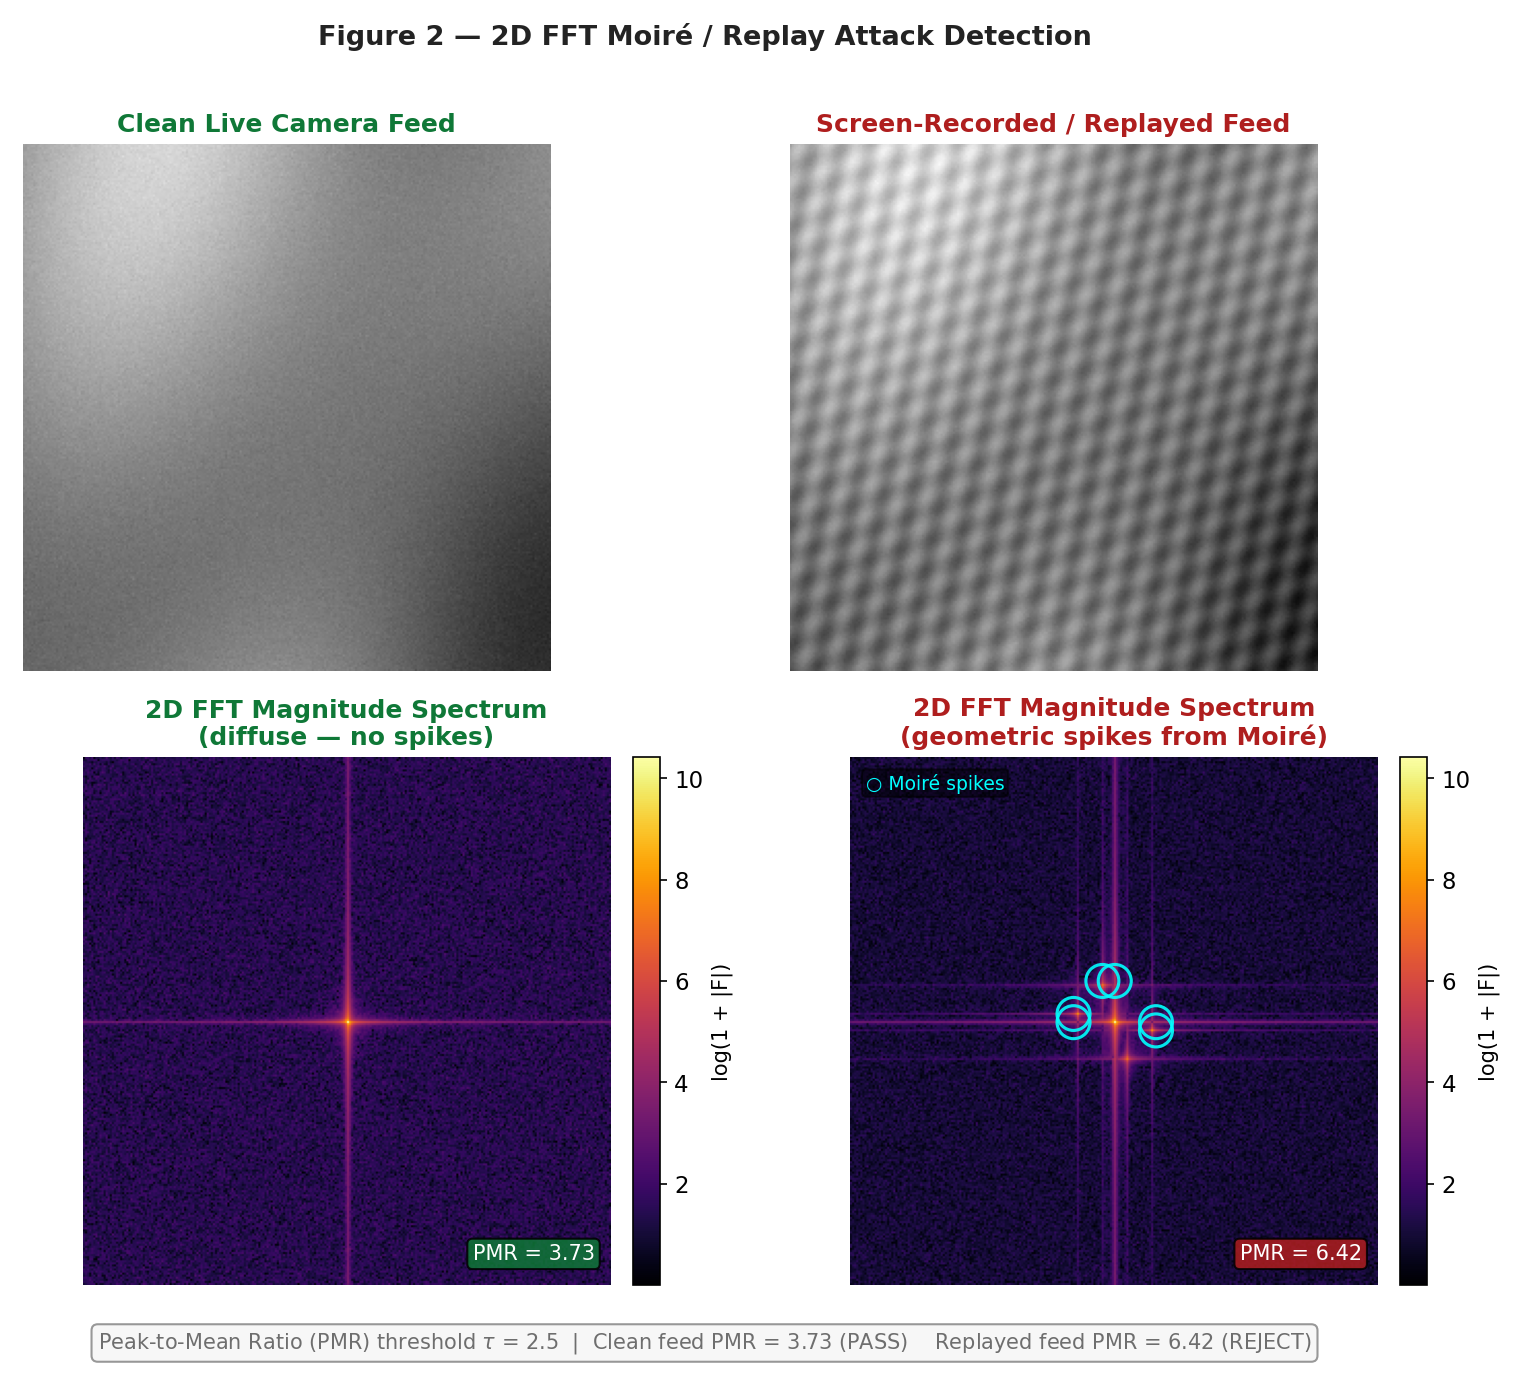

✓ Saved: figures/fig2_fft_moire.png


In [4]:
np.random.seed(7)

def make_clean_frame(h=256, w=256):
    """
    Simulate a clean camera frame: smooth scene + natural camera noise.
    The FFT of this should show only low-frequency scene energy + diffuse noise.
    """
    x, y = np.meshgrid(np.linspace(0, 2*np.pi, w),
                       np.linspace(0, 2*np.pi, h))
    # Smooth scene (low-frequency content only)
    scene  = 0.5 + 0.15 * np.sin(0.8 * x) + 0.12 * np.cos(0.6 * y)
    scene += 0.08 * np.sin(1.2 * x + 0.5 * y)
    scene  = scene.clip(0, 1)
    # Camera noise: white Gaussian
    noise  = np.random.randn(h, w) * 0.015
    return (scene + noise).clip(0, 1).astype(np.float32)


def make_moire_frame(h=256, w=256, screen_freq=18.5, angle_deg=12.0):
    """
    Simulate a frame captured from a digital screen.
    The screen pixel grid aliased against the camera sensor produces
    periodic Moire fringes at predictable spatial frequencies.

    screen_freq : cycles/frame (approx screen pixel pitch alias)
    angle_deg   : angle of the screen grid relative to camera sensor
    """
    x, y = np.meshgrid(np.linspace(0, 2*np.pi, w),
                       np.linspace(0, 2*np.pi, h))

    # Underlying scene (same as clean)
    scene  = 0.5 + 0.15 * np.sin(0.8 * x) + 0.12 * np.cos(0.6 * y)
    scene += 0.08 * np.sin(1.2 * x + 0.5 * y)
    scene  = scene.clip(0, 1)

    # Moire interference: periodic pattern from screen grid aliasing
    ang = np.deg2rad(angle_deg)
    xi  = np.linspace(0, screen_freq * 2 * np.pi, w)
    yi  = np.linspace(0, screen_freq * 2 * np.pi, h)
    XX, YY = np.meshgrid(xi, yi)
    moire  = 0.08 * np.sin(XX * np.cos(ang) + YY * np.sin(ang))
    moire += 0.05 * np.sin(XX * np.cos(ang + np.pi/3) +
                            YY * np.sin(ang + np.pi/3))

    # Camera noise (smaller — screen brightness is controlled)
    noise  = np.random.randn(h, w) * 0.008

    return (scene + moire + noise).clip(0, 1).astype(np.float32)


def compute_log_fft(img):
    """Compute centered 2D FFT log-magnitude spectrum."""
    F   = fft2(img)
    Fs  = fftshift(F)
    mag = np.log1p(np.abs(Fs))
    return mag


def compute_pmr(mag, inner_r=10, outer_r=100):
    """
    Peak-to-Mean Ratio in the mid-high frequency annulus.
    High PMR indicates localised spikes (Moire).
    """
    h, w  = mag.shape
    cy, cx = h // 2, w // 2
    Y, X  = np.ogrid[:h, :w]
    dist  = np.sqrt((X - cx)**2 + (Y - cy)**2)
    mask  = (dist >= inner_r) & (dist <= outer_r)
    ring  = mag[mask]
    return ring.max() / ring.mean()


# ── Generate frames and spectra ───────────────────────────────────────────────
clean_frame = make_clean_frame()
moire_frame = make_moire_frame()

clean_fft   = compute_log_fft(clean_frame)
moire_fft   = compute_log_fft(moire_frame)

pmr_clean   = compute_pmr(clean_fft)
pmr_moire   = compute_pmr(moire_fft)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(11, 8.5))
fig.suptitle('Figure 2 — 2D FFT Moiré / Replay Attack Detection',
             fontsize=13, fontweight='bold', color=DARKGRAY, y=1.01)

# Row 0: frames
axes[0, 0].imshow(clean_frame, cmap='gray', vmin=0, vmax=1)
axes[0, 0].set_title('Clean Live Camera Feed', color=SGREEN, fontweight='bold')
axes[0, 0].axis('off')

axes[0, 1].imshow(moire_frame, cmap='gray', vmin=0, vmax=1)
axes[0, 1].set_title('Screen-Recorded / Replayed Feed', color=SRED, fontweight='bold')
axes[0, 1].axis('off')

# Row 1: FFT spectra
vmin_shared = clean_fft.min()
vmax_shared = moire_fft.max()

im_c = axes[1, 0].imshow(clean_fft, cmap='inferno',
                          vmin=vmin_shared, vmax=vmax_shared)
axes[1, 0].set_title('2D FFT Magnitude Spectrum\n(diffuse — no spikes)',
                      color=SGREEN, fontweight='bold')
axes[1, 0].axis('off')
# Annotate PMR
axes[1, 0].text(0.97, 0.04, f'PMR = {pmr_clean:.2f}',
                transform=axes[1, 0].transAxes, ha='right', va='bottom',
                fontsize=10, color='white',
                bbox=dict(boxstyle='round,pad=0.25', fc=SGREEN, alpha=0.85))
plt.colorbar(im_c, ax=axes[1, 0], fraction=0.046, pad=0.03,
             label='log(1 + |F|)')

im_m = axes[1, 1].imshow(moire_fft, cmap='inferno',
                          vmin=vmin_shared, vmax=vmax_shared)
axes[1, 1].set_title('2D FFT Magnitude Spectrum\n(geometric spikes from Moiré)',
                      color=SRED, fontweight='bold')
axes[1, 1].axis('off')

# Annotate PMR
axes[1, 1].text(0.97, 0.04, f'PMR = {pmr_moire:.2f}',
                transform=axes[1, 1].transAxes, ha='right', va='bottom',
                fontsize=10, color='white',
                bbox=dict(boxstyle='round,pad=0.25', fc=SRED, alpha=0.85))

# Mark the Moire spike locations with circles
h_f, w_f = moire_fft.shape
cy_f, cx_f = h_f // 2, w_f // 2

# Find top-5 peaks in mid-high frequency region for annotation
Y, X = np.ogrid[:h_f, :w_f]
dist_grid = np.sqrt((X - cx_f)**2 + (Y - cy_f)**2)
annular   = ((dist_grid >= 20) & (dist_grid <= 110))
masked    = moire_fft.copy()
masked[~annular] = 0

# Simple local maxima annotation
from scipy.ndimage import label, maximum_position
thresh   = masked.max() * 0.85
binary   = (masked > thresh)
labeled, n_feat = label(binary)
for i in range(1, min(n_feat + 1, 7)):
    py, px = maximum_position(masked, labeled, i)
    circle = plt.Circle((px, py), 8, color='cyan',
                         fill=False, linewidth=1.5, alpha=0.9)
    axes[1, 1].add_patch(circle)

axes[1, 1].text(0.03, 0.97, '○ Moiré spikes',
                transform=axes[1, 1].transAxes, va='top',
                fontsize=9, color='cyan',
                bbox=dict(boxstyle='round,pad=0.2', fc='black', alpha=0.5))

plt.colorbar(im_m, ax=axes[1, 1], fraction=0.046, pad=0.03,
             label='log(1 + |F|)')

# Shared caption
fig.text(0.5, -0.03,
         f'Peak-to-Mean Ratio (PMR) threshold $\\tau$ = 2.5  |  '
         f'Clean feed PMR = {pmr_clean:.2f} (PASS)    '
         f'Replayed feed PMR = {pmr_moire:.2f} (REJECT)',
         ha='center', fontsize=10, color=MIDGRAY,
         bbox=dict(boxstyle='round,pad=0.3', fc='#F5F5F5', ec=MIDGRAY, alpha=0.7))

plt.tight_layout()
plt.savefig('figures/fig2_fft_moire.png')
plt.show()
print("✓ Saved: figures/fig2_fft_moire.png")

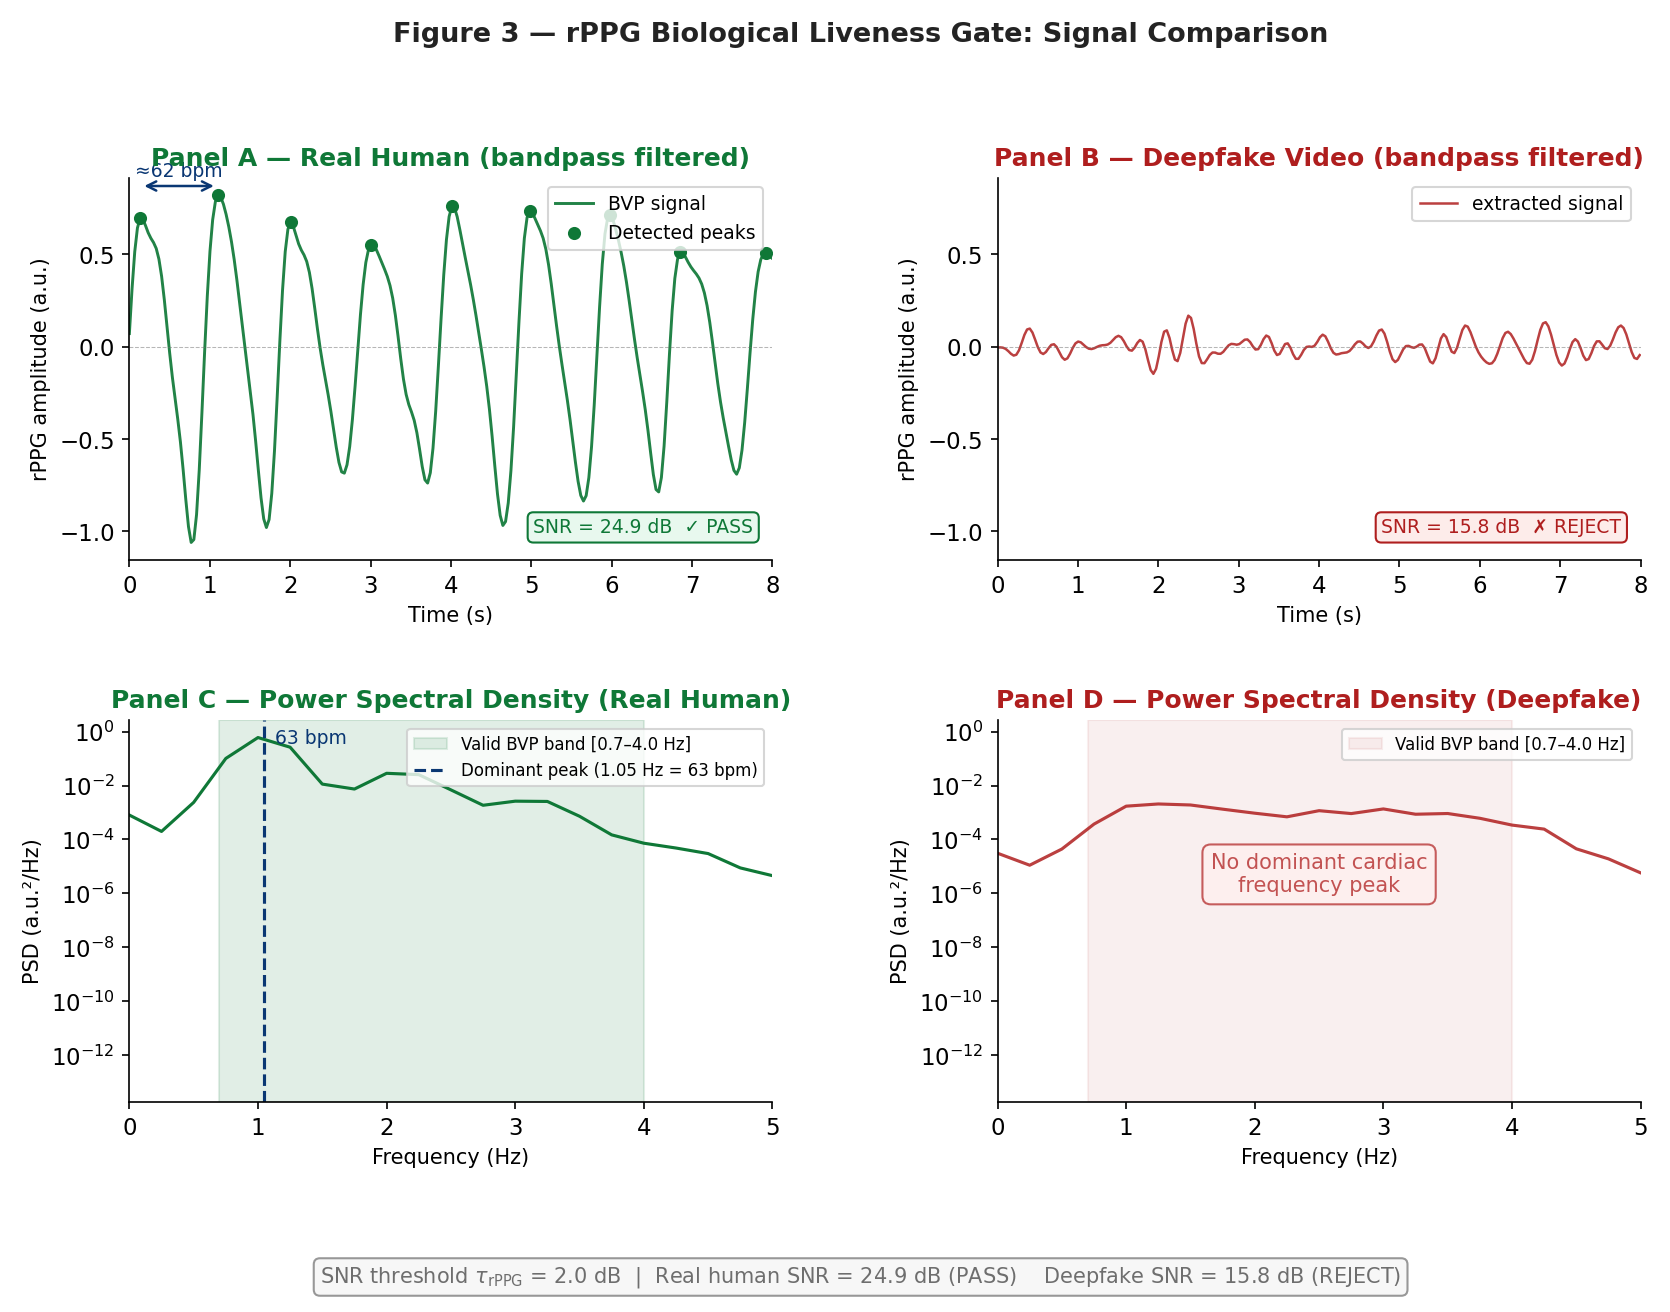

✓ Saved: figures/fig3_rppg_signals.png


In [5]:
np.random.seed(21)

# ── Parameters ────────────────────────────────────────────────────────────────
FPS         = 30        # camera framerate
DURATION    = 12        # seconds of signal
T           = FPS * DURATION
t           = np.linspace(0, DURATION, T)

HR_REAL     = 1.05      # Hz  — ~63 bpm (resting heart rate)
HR_HARMONIC = 2.10      # Hz  — 2nd harmonic
RESP_FREQ   = 0.25      # Hz  — breathing modulation (~15 breaths/min)


def make_real_rppg(t, hr=HR_REAL):
    """
    Simulate a realistic rPPG signal from a real human.
    - Dominant BVP peak at hr Hz with slight HRV jitter
    - Second harmonic
    - Respiratory modulation of amplitude
    - Realistic measurement noise
    """
    rng = np.random.default_rng(42)

    # Heart rate variability: small random jitter on instantaneous frequency
    hrv_jitter = 0.04 * np.cumsum(rng.standard_normal(len(t))) / np.sqrt(len(t))
    phase_bvp  = 2 * np.pi * (hr + hrv_jitter) * t

    # Primary BVP waveform (slightly non-sinusoidal — realistic)
    bvp_primary   = 0.70 * np.sin(phase_bvp)
    bvp_harmonic  = 0.18 * np.sin(2 * phase_bvp + 0.4)
    bvp_harmonic2 = 0.07 * np.sin(3 * phase_bvp + 0.8)

    # Respiratory amplitude modulation
    resp_mod = 1.0 + 0.22 * np.sin(2 * np.pi * RESP_FREQ * t)

    # Measurement noise (camera quantisation + motion)
    noise = rng.standard_normal(len(t)) * 0.06

    signal_raw = resp_mod * (bvp_primary + bvp_harmonic + bvp_harmonic2) + noise
    return signal_raw.astype(np.float64)


def make_fake_rppg(t):
    """
    Simulate the rPPG signal extracted from a deepfake video.
    - No coherent cardiac-band energy
    - Low-frequency rendering drift
    - Random noise without any dominant BVP peak
    """
    rng = np.random.default_rng(99)

    # Slow rendering drift (lighting inconsistency in the generator)
    drift = 0.15 * np.sin(2 * np.pi * 0.08 * t + 1.2) + \
            0.10 * np.sin(2 * np.pi * 0.15 * t + 0.5)

    # No BVP — just broadband noise
    noise = rng.standard_normal(len(t)) * 0.12

    return (drift + noise).astype(np.float64)


def bandpass_filter(sig, fs, lowcut=0.7, highcut=4.0, order=4):
    """Zero-phase Butterworth bandpass filter."""
    nyq = fs / 2.0
    b, a = signal.butter(order, [lowcut / nyq, highcut / nyq], btype='band')
    return signal.filtfilt(b, a, sig)


def pulse_snr(sig, fs, bvp_band=(0.7, 4.0)):
    """Compute pulse SNR as ratio of in-band to out-of-band PSD energy."""
    freqs, psd = signal.welch(sig, fs=fs, nperseg=fs * 4,
                               noverlap=fs * 2, window='hann')
    in_band  = (freqs >= bvp_band[0]) & (freqs <= bvp_band[1])
    out_band = ~in_band
    snr_db   = 10 * np.log10(psd[in_band].sum() / (psd[out_band].sum() + 1e-12))
    return snr_db, freqs, psd


# ── Generate signals ──────────────────────────────────────────────────────────
raw_real  = make_real_rppg(t)
raw_fake  = make_fake_rppg(t)

filt_real = bandpass_filter(raw_real, FPS)
filt_fake = bandpass_filter(raw_fake, FPS)

snr_real, freqs_real, psd_real = pulse_snr(filt_real, FPS)
snr_fake, freqs_fake, psd_fake = pulse_snr(filt_fake, FPS)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(13, 8))
gs  = gridspec.GridSpec(2, 2, hspace=0.42, wspace=0.35)

ax_tr  = fig.add_subplot(gs[0, 0])   # Panel A: real time-domain
ax_tf  = fig.add_subplot(gs[0, 1])   # Panel B: fake time-domain
ax_pr  = fig.add_subplot(gs[1, 0])   # Panel C: real PSD
ax_pf  = fig.add_subplot(gs[1, 1])   # Panel D: fake PSD

fig.suptitle('Figure 3 — rPPG Biological Liveness Gate: Signal Comparison',
             fontsize=13, fontweight='bold', color=DARKGRAY, y=1.01)

# ── Panel A — Real time-domain ────────────────────────────────────────────────
t_show = 8.0   # show first 8 seconds for clarity
mask_t = t <= t_show

ax_tr.plot(t[mask_t], filt_real[mask_t],
           color=SGREEN, linewidth=1.4, alpha=0.92, label='BVP signal')
ax_tr.axhline(0, color=MIDGRAY, linewidth=0.5, linestyle='--', alpha=0.5)
ax_tr.set_title('Panel A — Real Human (bandpass filtered)', color=SGREEN)
ax_tr.set_xlabel('Time (s)')
ax_tr.set_ylabel('rPPG amplitude (a.u.)')
ax_tr.set_xlim(0, t_show)

# Annotate heartbeat peaks
peaks, _ = signal.find_peaks(filt_real, height=0.2, distance=FPS * 0.55)
peaks_show = peaks[t[peaks] <= t_show]
ax_tr.scatter(t[peaks_show], filt_real[peaks_show],
              color=SGREEN, s=28, zorder=5, label='Detected peaks')
ax_tr.legend(fontsize=9, loc='upper right')

# Period annotation on first two peaks
if len(peaks_show) >= 2:
    p1, p2 = t[peaks_show[0]], t[peaks_show[1]]
    yp = filt_real[peaks_show[0]] * 1.25
    ax_tr.annotate('', xy=(p2, yp), xytext=(p1, yp),
                   arrowprops=dict(arrowstyle='<->', color=PRIMARY, lw=1.2))
    hr_est = 60 / (p2 - p1)
    ax_tr.text((p1 + p2) / 2, yp * 1.06, f'≈{hr_est:.0f} bpm',
               ha='center', fontsize=9, color=PRIMARY)

ax_tr.text(0.97, 0.06, f'SNR = {snr_real:.1f} dB  ✓ PASS',
           transform=ax_tr.transAxes, ha='right', va='bottom',
           fontsize=9, color=SGREEN,
           bbox=dict(boxstyle='round,pad=0.3', fc='#E8F8EE', ec=SGREEN))

# ── Panel B — Fake time-domain ────────────────────────────────────────────────
ax_tf.plot(t[mask_t], filt_fake[mask_t],
           color=SRED, linewidth=1.2, alpha=0.85, label='extracted signal')
ax_tf.axhline(0, color=MIDGRAY, linewidth=0.5, linestyle='--', alpha=0.5)
ax_tf.set_title('Panel B — Deepfake Video (bandpass filtered)', color=SRED)
ax_tf.set_xlabel('Time (s)')
ax_tf.set_ylabel('rPPG amplitude (a.u.)')
ax_tf.set_xlim(0, t_show)
ax_tf.set_ylim(ax_tr.get_ylim())   # same y-scale for fair comparison
ax_tf.legend(fontsize=9, loc='upper right')
ax_tf.text(0.97, 0.06, f'SNR = {snr_fake:.1f} dB  ✗ REJECT',
           transform=ax_tf.transAxes, ha='right', va='bottom',
           fontsize=9, color=SRED,
           bbox=dict(boxstyle='round,pad=0.3', fc='#FDECEA', ec=SRED))

# ── Panel C — Real PSD ────────────────────────────────────────────────────────
ax_pr.semilogy(freqs_real, psd_real, color=SGREEN, linewidth=1.5)
ax_pr.axvspan(0.7, 4.0, alpha=0.12, color=SGREEN, label='Valid BVP band [0.7–4.0 Hz]')
ax_pr.axvline(HR_REAL, color=PRIMARY, linewidth=1.5, linestyle='--',
              label=f'Dominant peak ({HR_REAL:.2f} Hz = {HR_REAL*60:.0f} bpm)')
ax_pr.set_title('Panel C — Power Spectral Density (Real Human)', color=SGREEN)
ax_pr.set_xlabel('Frequency (Hz)')
ax_pr.set_ylabel('PSD (a.u.²/Hz)')
ax_pr.set_xlim(0, 5)
ax_pr.legend(fontsize=8, loc='upper right')
ax_pr.text(HR_REAL + 0.08, psd_real.max() * 0.6,
           f'{HR_REAL*60:.0f} bpm', color=PRIMARY, fontsize=9)

# ── Panel D — Fake PSD ────────────────────────────────────────────────────────
ax_pf.semilogy(freqs_fake, psd_fake, color=SRED, linewidth=1.5, alpha=0.85)
ax_pf.axvspan(0.7, 4.0, alpha=0.07, color=SRED, label='Valid BVP band [0.7–4.0 Hz]')
ax_pf.set_title('Panel D — Power Spectral Density (Deepfake)', color=SRED)
ax_pf.set_xlabel('Frequency (Hz)')
ax_pf.set_ylabel('PSD (a.u.²/Hz)')
ax_pf.set_xlim(0, 5)
ax_pf.set_ylim(ax_pr.get_ylim())   # same y-scale
ax_pf.legend(fontsize=8, loc='upper right')
ax_pf.text(0.5, 0.55,
           'No dominant cardiac\nfrequency peak',
           transform=ax_pf.transAxes, ha='center', fontsize=10,
           color=SRED, alpha=0.75,
           bbox=dict(boxstyle='round,pad=0.4', fc='#FFF0EE', ec=SRED, alpha=0.7))

# ── Global caption ────────────────────────────────────────────────────────────
fig.text(0.5, -0.04,
         f'SNR threshold $\\tau_{{\\mathrm{{rPPG}}}}$ = 2.0 dB  |  '
         f'Real human SNR = {snr_real:.1f} dB (PASS)    '
         f'Deepfake SNR = {snr_fake:.1f} dB (REJECT)',
         ha='center', fontsize=10, color=MIDGRAY,
         bbox=dict(boxstyle='round,pad=0.3', fc='#F5F5F5', ec=MIDGRAY, alpha=0.7))

plt.savefig('figures/fig3_rppg_signals.png')
plt.show()
print("✓ Saved: figures/fig3_rppg_signals.png")

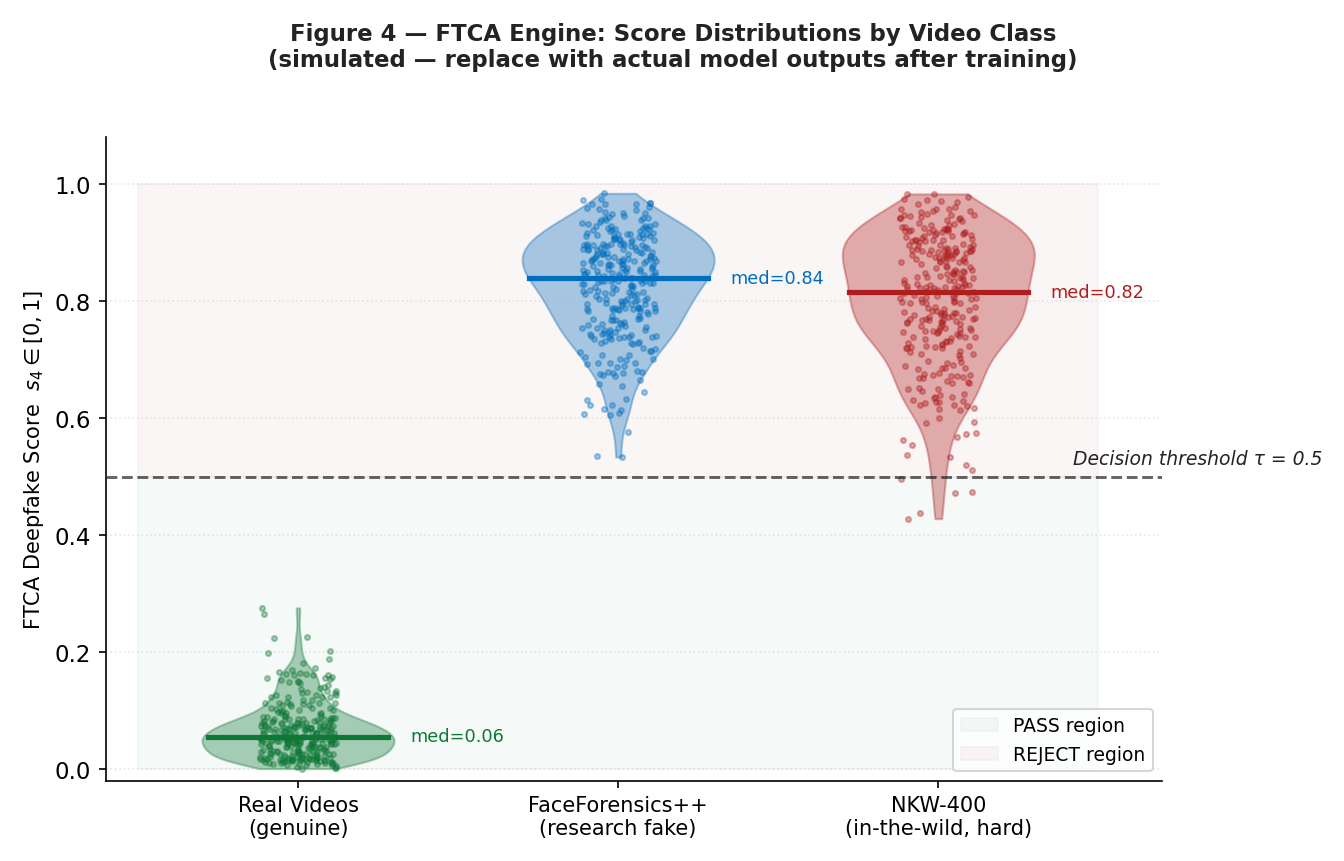

✓ Saved: figures/fig4_ftca_scores.png


In [6]:
np.random.seed(55)

def beta_clipped(a, b, size, low=0.0, high=1.0):
    """Sample from a beta distribution, scaled to [low, high]."""
    s = np.random.beta(a, b, size)
    return low + s * (high - low)

# Simulate score distributions
n = 300
scores_real   = beta_clipped(1.5, 9.0,   n, 0.00, 0.45)   # real: clustered near 0
scores_ff     = beta_clipped(7.0, 2.5,   n, 0.35, 1.00)   # FF++: high but some overlap
scores_nkw    = beta_clipped(4.5, 2.0,   n, 0.30, 1.00)   # NKW-400: harder, wider spread

categories = {
    'Real Videos\n(genuine)':          (scores_real,  SGREEN),
    'FaceForensics++\n(research fake)': (scores_ff,    ACCENT),
    'NKW-400\n(in-the-wild, hard)':    (scores_nkw,   SRED),
}

fig, ax = plt.subplots(figsize=(9, 5.5))
fig.suptitle('Figure 4 — FTCA Engine: Score Distributions by Video Class\n'
             '(simulated — replace with actual model outputs after training)',
             fontsize=11, fontweight='bold', color=DARKGRAY, y=1.02)

positions = [1, 2, 3]
for pos, (label, (data, color)) in zip(positions, categories.items()):
    parts = ax.violinplot(data, positions=[pos], widths=0.6,
                          showmedians=False, showextrema=False)
    for pc in parts['bodies']:
        pc.set_facecolor(color)
        pc.set_alpha(0.35)
        pc.set_edgecolor(color)

    # Strip plot (jittered dots)
    jitter = np.random.uniform(-0.12, 0.12, len(data))
    ax.scatter(pos + jitter, data, color=color, alpha=0.35, s=6, zorder=3)

    # Median line
    med = np.median(data)
    ax.plot([pos - 0.28, pos + 0.28], [med, med],
            color=color, linewidth=2.5, zorder=4)

    # IQR annotation
    q1, q3 = np.percentile(data, [25, 75])
    ax.text(pos + 0.35, med, f'med={med:.2f}',
            va='center', fontsize=8.5, color=color)

# Decision threshold line
THRESHOLD = 0.50
ax.axhline(THRESHOLD, color=DARKGRAY, linewidth=1.4,
           linestyle='--', alpha=0.7, zorder=5)
ax.text(3.42, THRESHOLD + 0.015, f'Decision threshold τ = {THRESHOLD}',
        va='bottom', fontsize=9, color=DARKGRAY, style='italic')

ax.fill_between([0.5, 3.5], 0, THRESHOLD,
                color=SGREEN, alpha=0.04, label='PASS region')
ax.fill_between([0.5, 3.5], THRESHOLD, 1.0,
                color=SRED, alpha=0.04, label='REJECT region')

ax.set_xticks(positions)
ax.set_xticklabels(list(categories.keys()), fontsize=10)
ax.set_ylabel('FTCA Deepfake Score  $s_4 \\in [0, 1]$', fontsize=10)
ax.set_ylim(-0.02, 1.08)
ax.set_xlim(0.4, 3.7)
ax.legend(fontsize=9, loc='lower right')
ax.yaxis.grid(True, alpha=0.3, linestyle=':')

plt.tight_layout()
plt.savefig('figures/fig4_ftca_scores.png')
plt.show()
print("✓ Saved: figures/fig4_ftca_scores.png")

In [7]:
latex_snippets = {
    'fig1_prnu_residuals.png': (
        'Figure 2 (PRNU)',
        r'''\begin{figure}[H]
\centering
\includegraphics[width=0.92\linewidth]{figures/fig1_prnu_residuals.png}
\caption{PRNU noise residuals: physical camera (left) vs.\ OBS virtual camera (right).
Real cameras show a structured fingerprint; software-rendered frames do not.}
\label{fig:prnu_residuals}
\end{figure}'''
    ),
    'fig2_fft_moire.png': (
        'Figure 3 (Moire FFT)',
        r'''\begin{figure}[H]
\centering
\includegraphics[width=0.92\linewidth]{figures/fig2_fft_moire.png}
\caption{2D FFT magnitude spectra. Clean feed (left): diffuse isotropic energy.
Screen-recorded feed (right): geometric Moir\'{e} spike pattern detected by PMR.}
\label{fig:fft_moire}
\end{figure}'''
    ),
    'fig3_rppg_signals.png': (
        'Figure 5 (rPPG)',
        r'''\begin{figure}[H]
\centering
\includegraphics[width=0.92\linewidth]{figures/fig3_rppg_signals.png}
\caption{rPPG pulse signal comparison. Real human (green): coherent cardiac peak in
PSD, high SNR. Deepfake (red): no dominant frequency, SNR below rejection threshold.}
\label{fig:rppg_signals}
\end{figure}'''
    ),
    'fig4_ftca_scores.png': (
        'Figure 6 (FTCA Score Distribution)',
        r'''\begin{figure}[H]
\centering
\includegraphics[width=0.80\linewidth]{figures/fig4_ftca_scores.png}
\caption{FTCA score distributions for real videos, FaceForensics++ deepfakes,
and NKW-400 in-the-wild hard samples. Dashed line shows the decision threshold
$\tau = 0.5$.}
\label{fig:ftca_scores}
\end{figure}'''
    ),
}

print("=" * 64)
print("  ALL FIGURES GENERATED — Copy these LaTeX snippets into your report")
print("=" * 64)
for fname, (title, snippet) in latex_snippets.items():
    fpath = f'figures/{fname}'
    exists = "✓" if os.path.exists(fpath) else "✗ MISSING"
    print(f"\n{exists}  {title}  ({fpath})")
    print("-" * 56)
    print(snippet)
    print()

# Download helper (Colab)
try:
    from google.colab import files
    print("\nDownloading all figures...")
    for fname in latex_snippets:
        fpath = f'figures/{fname}'
        if os.path.exists(fpath):
            files.download(fpath)
    print("✓ All figures downloaded.")
except ImportError:
    print("\nNot running in Colab — figures are in ./figures/")

  ALL FIGURES GENERATED — Copy these LaTeX snippets into your report

✓  Figure 2 (PRNU)  (figures/fig1_prnu_residuals.png)
--------------------------------------------------------
\begin{figure}[H]
\centering
\includegraphics[width=0.92\linewidth]{figures/fig1_prnu_residuals.png}
\caption{PRNU noise residuals: physical camera (left) vs.\ OBS virtual camera (right).
Real cameras show a structured fingerprint; software-rendered frames do not.}
\label{fig:prnu_residuals}
\end{figure}


✓  Figure 3 (Moire FFT)  (figures/fig2_fft_moire.png)
--------------------------------------------------------
\begin{figure}[H]
\centering
\includegraphics[width=0.92\linewidth]{figures/fig2_fft_moire.png}
\caption{2D FFT magnitude spectra. Clean feed (left): diffuse isotropic energy.
Screen-recorded feed (right): geometric Moir\'{e} spike pattern detected by PMR.}
\label{fig:fft_moire}
\end{figure}


✓  Figure 5 (rPPG)  (figures/fig3_rppg_signals.png)
-----------------------------------------------------

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ All figures downloaded.
